# **DATA ANALYTICS INTERNSHIP**

**Intern:** Narmadha V  
**Organization:** DecodeLabs  
**Batch:** 2026  

## **Project 2 : Exploratory Data Analysis (EDA)** 

### Step 1: Dataset Overview

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_excel("Cleaned_Dataset.xlsx")
print(df.head())
print()
df.info()

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  CalculatedPrice  
0     SAVE10      Instagram     2853.10          2853.10  
1     SAVE10       Ref

### Step 2: Descriptive Statistics

In [4]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,CalculatedPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558,819.856558


In [5]:
df.median(numeric_only=True)

Quantity             3.000
UnitPrice          364.210
ItemsInCart          5.000
TotalPrice         823.615
CalculatedPrice    823.615
dtype: float64

### Step 3: Verify Missing Values

In [6]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
CalculatedPrice    0
dtype: int64

### Step 4: Identify Numerical Columns

In [7]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

print("Numerical Columns:")
print(numeric_cols)

Numerical Columns:
Index(['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice',
       'CalculatedPrice'],
      dtype='object')


### Step 5: Distribution Analysis

#### **1. Correlation Heatmap**

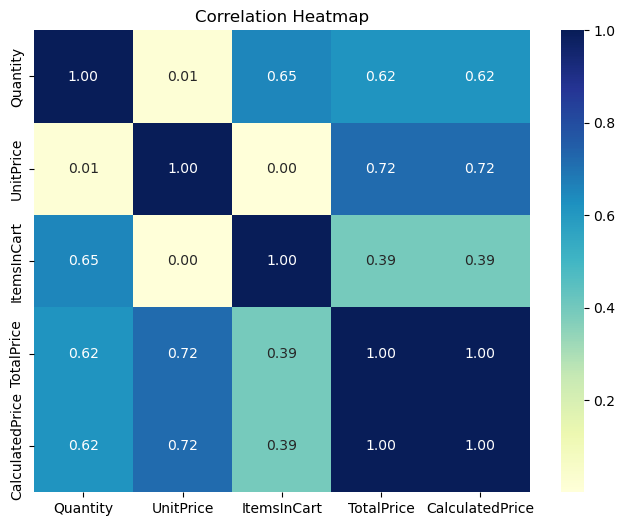

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='YlGnBu',fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

- Total Price is influenced more by Unit Price (0.72) and Quantity (0.62) than by Items in Cart (0.39). Unit Price and Items in Cart show almost no relationship.

#### **2. Quantity vs TotalPrice**

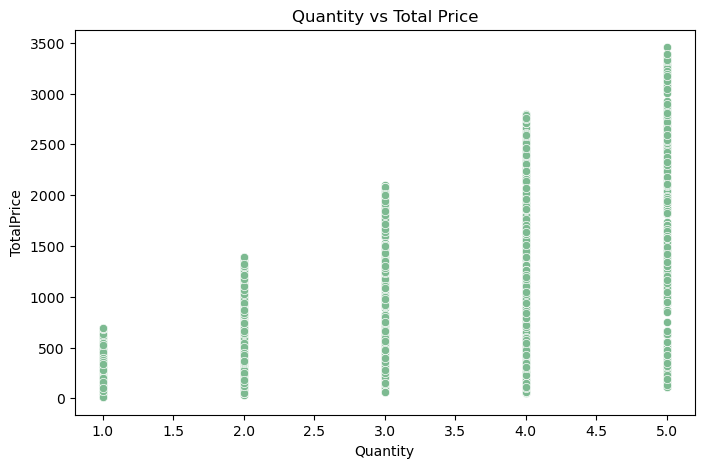

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Quantity',y='TotalPrice',data=df)
sns.set_palette("crest")
plt.title('Quantity vs Total Price')
plt.show()

- Total transaction value increased as customers purchased more units, indicating quantity directly influenced spending.

#### **3. UnitPrice vs TotalPrice**

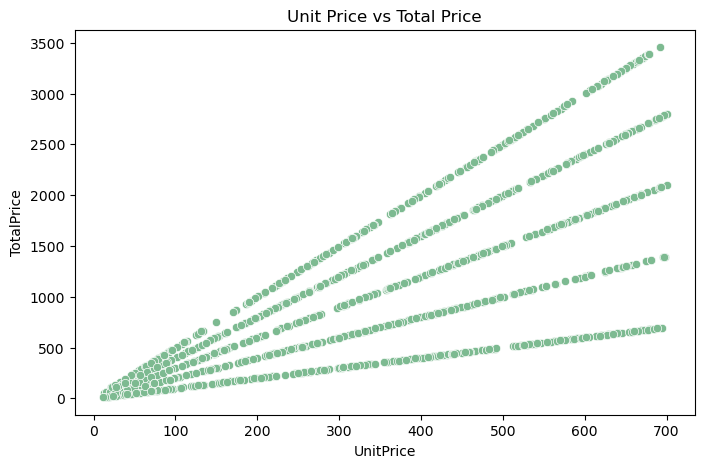

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='UnitPrice',y='TotalPrice',data=df)
sns.set_palette("crest")
plt.title('Unit Price vs Total Price')
plt.show()

- Higher unit prices consistently resulted in higher total transaction values, showing a strong positive relationship.

#### **4. Distribution of TotalPrice Only**

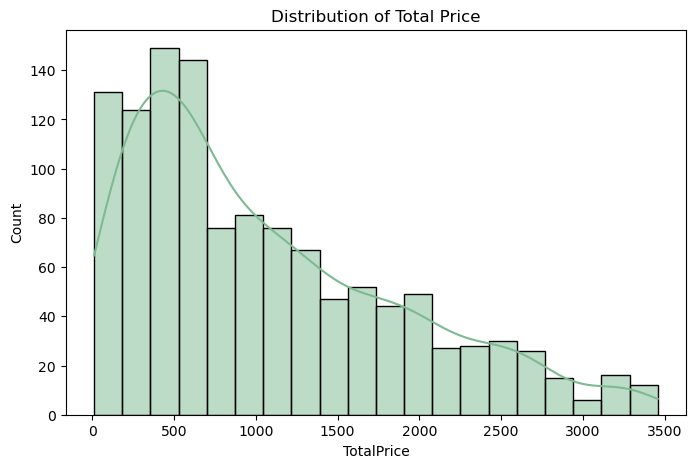

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalPrice'], bins=20, kde=True)
sns.set_palette("crest")
plt.title('Distribution of Total Price')
plt.show()

- Most transactions were concentrated at lower total prices, with fewer high-value purchases.

#### **5. Monthly Sales Trend**

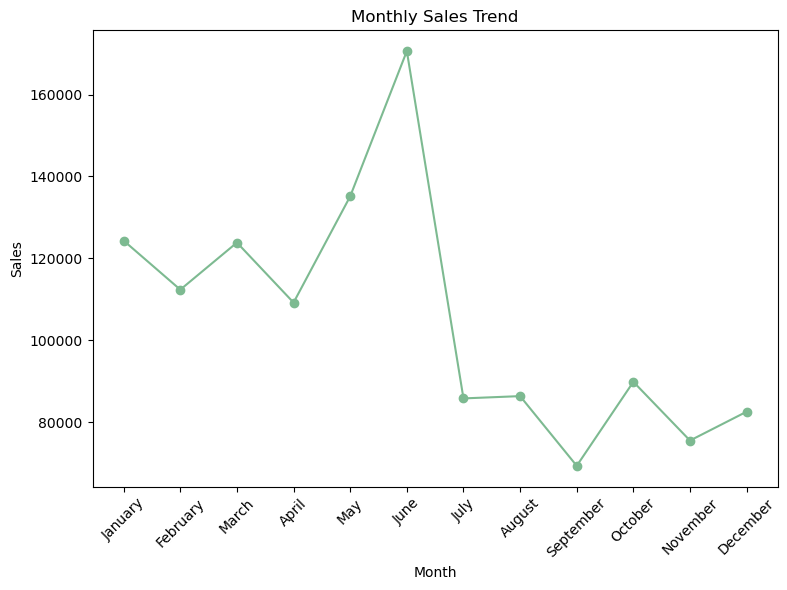

In [12]:
import matplotlib.pyplot as plt

df['Month'] = df['Date'].dt.month_name()

month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

monthly_sales = (df.groupby('Month')['TotalPrice'].sum().reindex(month_order))

plt.figure(figsize=(8,6))

monthly_sales.plot(kind='line',marker='o')

# Force every month label
plt.xticks(ticks=range(len(month_order)),labels=month_order,rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
sns.set_palette("crest")
plt.tight_layout()

plt.show()

- Sales peaked in **June**, suggesting stronger customer purchasing during this period.

#### **6. Top Product Sales**

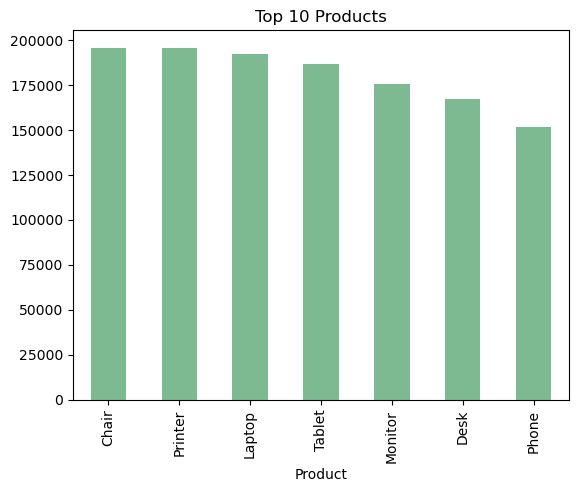

In [16]:
top_products = (df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(10))

top_products.plot(kind='bar')
sns.set_palette("crest")
plt.title("Top 10 Products")

plt.show()

- Some products generated higher sales revenue compared to others.

#### **7. Payment Method Distribution**

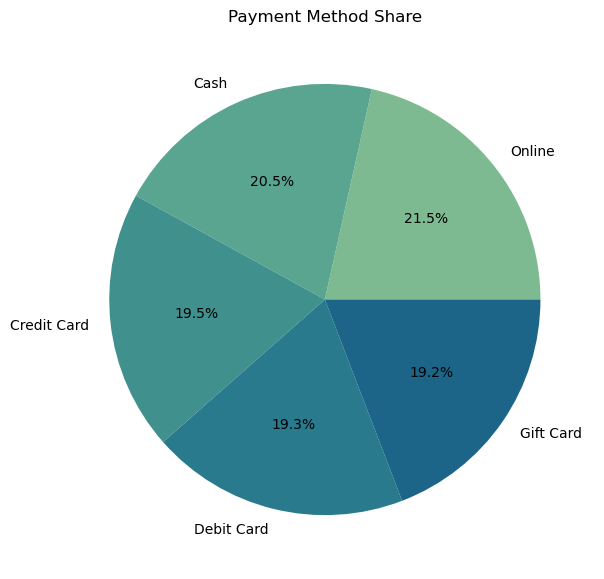

In [14]:
payment = df['PaymentMethod'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(payment, labels=payment.index, autopct='%1.1f%%')
sns.set_palette("YlGnBu")
plt.title("Payment Method Share")

plt.show()

- Payment usage remained fairly distributed across available payment methods.

#### **8. Customer Spend Distribution**

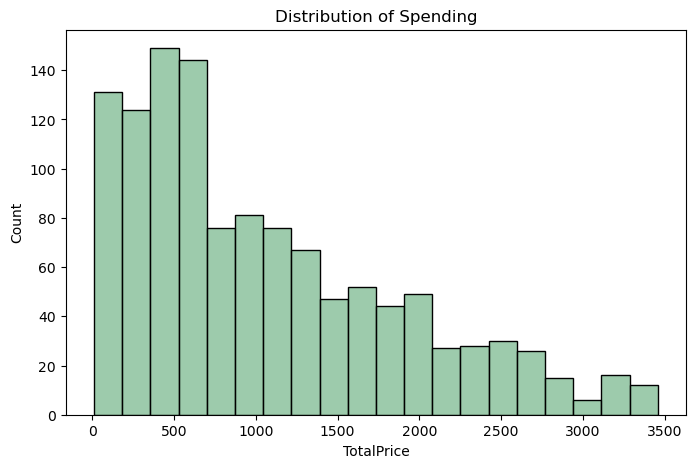

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalPrice'],bins=20)
sns.set_palette("crest")
plt.title("Distribution of Spending")

plt.show()

- Most customer purchases were concentrated within lower spending ranges, with fewer high-value transactions.

### Outlier Detection using IQR Method

In [20]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 410.52
Q3: 1578.475
IQR: 1167.955
Lower Bound: -1341.4125
Upper Bound: 3330.4075


In [21]:
outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print("Number of Outliers:", len(outliers))

Number of Outliers: 8


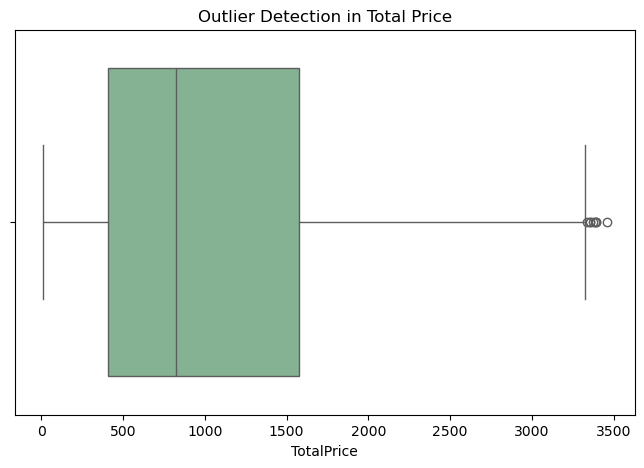

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['TotalPrice'])
sns.set_palette("crest")
plt.title('Outlier Detection in Total Price')
plt.show()

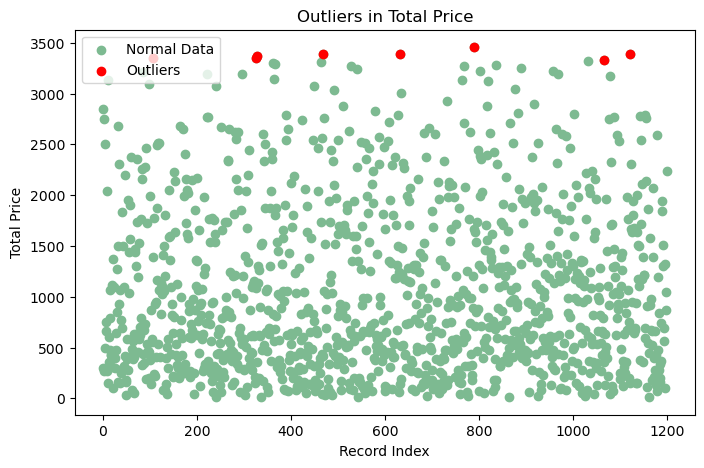

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(df.index, df['TotalPrice'], label='Normal Data')

plt.scatter(outliers.index, outliers['TotalPrice'], color='red', label='Outliers')
sns.set_palette("crest")
plt.title('Outliers in Total Price')
plt.xlabel('Record Index')
plt.ylabel('Total Price')
plt.legend()

plt.show()

- Most transactions remained within the normal spending range, with a few exceptionally high-value orders.

### Step 6: Trend Analysis

In [25]:
#High Value Tansacitons
top_orders = df.nlargest(10, 'TotalPrice')

top_orders[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']]

,Quantity,UnitPrice,ItemsInCart,TotalPrice
789,5,691.28,10,3456.40
1122,5,678.19,8,3390.95
632,5,678.16,7,3390.80
469,5,676.98,5,3384.90
328,5,674.04,7,3370.20
107,5,670.75,8,3353.75
326,5,670.48,5,3352.40
1065,5,666.80,7,3334.00
1031,5,664.51,8,3322.55
463,5,662.78,9,3313.90


In [26]:
#Low Value Transactions
lowest_orders = df.nsmallest(10, 'TotalPrice')

lowest_orders[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']]

,Quantity,UnitPrice,ItemsInCart,TotalPrice
1161,1,11.39,6,11.39
863,1,14.06,5,14.06
240,1,17.24,2,17.24
542,1,17.98,6,17.98
336,1,18.20,4,18.20
776,1,21.19,5,21.19
1025,1,23.53,2,23.53
690,1,24.48,1,24.48
926,1,26.95,1,26.95
473,2,14.93,4,29.86


### Step 7: Statistical Summary

In [28]:
#Average metrics
print("Average Quantity:", round(df['Quantity'].mean(), 2))
print("Average Unit Price:", round(df['UnitPrice'].mean(), 2))
print("Average Items In Cart:", round(df['ItemsInCart'].mean(), 2))
print("Average Total Price:", round(df['TotalPrice'].mean(), 2))

Average Quantity: 2.95
Average Unit Price: 356.41
Average Items In Cart: 5.48
Average Total Price: 1053.97


### Step 8: Dataset Summary

In [29]:
print("DATASET SUMMARY")
print("-" * 40)

print("Total Records:", len(df))
print()

print("Average Quantity:", round(df['Quantity'].mean(), 2))
print("Average Unit Price:", round(df['UnitPrice'].mean(), 2))
print("Average Items In Cart:", round(df['ItemsInCart'].mean(), 2))
print("Average Total Price:", round(df['TotalPrice'].mean(), 2))
print()

print("Maximum Total Price:", df['TotalPrice'].max())
print("Minimum Total Price:", df['TotalPrice'].min())
print()

print("Number of Outliers:", len(outliers))

DATASET SUMMARY
----------------------------------------
Total Records: 1200

Average Quantity: 2.95
Average Unit Price: 356.41
Average Items In Cart: 5.48
Average Total Price: 1053.97

Maximum Total Price: 3456.4
Minimum Total Price: 11.39

Number of Outliers: 8


## Key Insights and Observations

- The dataset was cleaned successfully and is ready for analysis.

- Quantity and UnitPrice have a strong impact on TotalPrice.

- Most transactions fall within a normal price range.

- A few high-value transactions were identified as outliers.

- Higher quantities generally result in higher transaction values.

- Customer purchasing behavior varies across different transactions.

- Visualizations helped identify trends, distributions, and unusual records.

- Overall, the analysis revealed important patterns that can support better business decisions.